In [175]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from typing import List, Optional, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.runnables import RunnableConfig

# Load environmental variables from .env
load_dotenv()

True

In [176]:
import json
from typing import Any, Dict
from langchain_core.messages import BaseMessage


def dump_state(state: Dict[str, Any], indent: int = 2, show_message_content: bool = True) -> None:
    """
    Pretty print entire LangGraph state including messages.

    Args:
        state: The state dictionary from LangGraph
        indent: Number of spaces for JSON indentation
        show_message_content: If True, shows full message content. If False, shows truncated preview.
    """
    serializable_state = {}

    for key, value in state.items():
        if key == "messages":
            # Convert messages to serializable format
            serializable_state["messages"] = [
                serialize_message(msg, show_full_content=show_message_content)
                for msg in value
            ]
        elif isinstance(value, list):
            # Handle lists that might contain complex objects
            serializable_state[key] = [
                serialize_item(item) for item in value
            ]
        else:
            # Handle other types
            serializable_state[key] = serialize_item(value)

    print(json.dumps(serializable_state, indent=indent, ensure_ascii=False))


def serialize_message(msg: BaseMessage, show_full_content: bool = True) -> Dict[str, Any]:
    """Convert a LangChain message to a serializable dict."""
    content = msg.content if show_full_content else f"{msg.content[:100]}..." if len(msg.content) > 100 else msg.content

    result = {
        "type": msg.type,
        "content": content
    }

    # Include additional fields if present
    if hasattr(msg, 'name') and msg.name:
        result["name"] = msg.name
    if hasattr(msg, 'id') and msg.id:
        result["id"] = msg.id

    return result


def serialize_item(item: Any) -> Any:
    """Serialize various types to JSON-compatible format."""
    if isinstance(item, BaseMessage):
        return serialize_message(item)
    elif hasattr(item, 'dict'):
        # Pydantic models
        return item.dict()
    elif hasattr(item, '__dict__'):
        # Generic objects
        return item.__dict__
    else:
        # Primitive types
        return item


def dump_state_compact(state: Dict[str, Any]) -> None:
    """
    Compact view of state - good for quick inspection.
    Shows message count and truncated content.
    """
    print("=== STATE SNAPSHOT ===")
    print(f"City: {state.get('city', 'N/A')}")
    print(f"Interests: {state.get('activity', [])}")
    print(f"Activities: {len(state.get('activities_offers', []))} items")
    print(f"Sights: {len(state.get('pois_offers', []))} items")
    print(f"Messages: {len(state.get('messages', []))} total")

    if state.get('messages'):
        print("\nLast message:")
        last_msg = state['messages'][-1]
        content_preview = last_msg.content[:150] + "..." if len(last_msg.content) > 150 else last_msg.content
        print(f"  [{last_msg.type}]: {content_preview}")


def dump_state_detailed(state: Dict[str, Any]) -> None:
    """
    Detailed view with full content - good for debugging.
    """
    print("=== DETAILED STATE ===\n")

    print(f"City: {state.get('city', 'N/A')}\n")

    print("Activitiy:")
    for i, actvt in enumerate(state.get('activity', []), 1):
        print(f"  {i}. {actvt}")

    print("\nActivities_offer:")
    for i, activity in enumerate(state.get('activities_offer', []), 1):
        print(f"  {i}. {activity}")

    print("\nPOIs:")
    for i, poi in enumerate(state.get('pois_offers', []), 1):
        print(f"  {i}. {poi}")

    print(f"\nTrip Plan Length: {len(state.get('result', ''))} characters")

    print(f"\n=== MESSAGES ({len(state.get('messages', []))}) ===")
    for i, msg in enumerate(state.get('messages', []), 1):
        print(f"\nMessage {i} [{msg.type}]:")
        print(f"  {msg.content[:200]}..." if len(msg.content) > 200 else f"  {msg.content}")


# Example usage in notebook:
"""
# Import the function
from state_printer import dump_state, dump_state_compact, dump_state_detailed

# After invoking your graph
final_result = app.invoke(...)

# Option 1: Full JSON dump
dump_state(final_result)

# Option 2: Compact view
dump_state_compact(final_result)

# Option 3: Detailed human-readable view
dump_state_detailed(final_result)

# Option 4: JSON with truncated messages
dump_state(final_result, show_message_content=False)
"""

'\n# Import the function\nfrom state_printer import dump_state, dump_state_compact, dump_state_detailed\n\n# After invoking your graph\nfinal_result = app.invoke(...)\n\n# Option 1: Full JSON dump\ndump_state(final_result)\n\n# Option 2: Compact view\ndump_state_compact(final_result)\n\n# Option 3: Detailed human-readable view\ndump_state_detailed(final_result)\n\n# Option 4: JSON with truncated messages\ndump_state(final_result, show_message_content=False)\n'

In [177]:
llm = init_chat_model("gpt-4o-mini")

llm_genai = init_chat_model(
    model="gemini-2.5-flash-lite",
    model_provider="google_genai"
)


## **Define state and create a graph**

In [178]:
from langgraph.graph import add_messages


def coalesce_deprecated(old: Optional[str], new: Optional[str]) -> Optional[str]:
    return new or old

class POI(BaseModel):
    """Point of Interest in the city"""
    name: str = Field(..., description="Name of the point of interest")
    description: str = Field(..., description="Brief description of the POI")
    why_visit: str = Field(..., description="Why this POI is worth visiting")

class Activity(BaseModel):
    """Activity offer related to user's interest"""
    name: str = Field(..., description="Name of the activity or place")
    description: str = Field(..., description="Description of the activity")
    relevance: str = Field(..., description="How this relates to the user's requested activity")

class TravelGuideState(BaseModel):
    """State that flows through the travel guide graph"""
    messages: Annotated[list[AnyMessage], add_messages] = Field(default_factory=list, description="Conversation history")
    city: str = Field(..., description="Name of the city to visit")
    activity: Optional[str] = Field(default=None, description="Optional activity focus (e.g., 'museums', 'food', 'nightlife')")
    pois_offers: List[POI] = Field(default_factory=list, description="List of 3 general points of interest in the city")
    activities_offers: List[Activity] = Field(default_factory=list, description="List of 3 activity-specific offers")
    result: Annotated[str, operator.add] = Field(default="", description="Formatted markdown combining city overview, POIs, and activities")

graph = StateGraph(TravelGuideState)



##**Nodes**

In [179]:
class RespStructure(BaseModel):
    city: str = Field(description="Name of the city to visit")
    activity: Optional[str] = Field(default=None, description="Single activity focus if mentioned")


def collect_preferences(state: TravelGuideState) -> dict:
    print("## Running collect_preferences node ##")

    text = state.messages[-1].content if state.messages else ""
    prompt = f"""
From the following user input:
<user_input>
{text}
</user_input>

extract information about the city name and user's interests. User interests can be empty if no new information appears.
"""
    result = llm.with_structured_output(RespStructure).invoke(prompt)
    print("#" * 30)
    print(result)
    print("#" * 30)
    return {"city": result.city, "activity": result.activity}

def ask_pois(state: TravelGuideState) -> dict:

    # Create a wrapper model for the list
    class POIList(BaseModel):
        pois: List[POI] = Field(description="List of 3 points of interest")

    print("## Running ask_sights node ##")
    prompt = f"""Suggest 3 must-visit points of interest in {state.city}.
    For each POI, provide: name, brief description, and why visitors should go there."""

    result = llm_genai.with_structured_output(schema=POIList).invoke(prompt)
    return {"pois_offers": result.pois}



def ask_activities(state: TravelGuideState) -> dict:
    print("## Running ask_activities node ##")
    if not state.activity:
        print("   (No activity focus - skipping)")
        return {"activities_offers": []}

    # Create a wrapper model for the list
    class ActivityList(BaseModel):
        activities: List[Activity] = Field(description="List of 3 activities")


    prompt = f"""User is visiting {state.city} and is interested in: {state.activity}.
    Suggest 3 specific activities or places related to this interest.
    For each, provide: name, description, and why it's relevant to {state.activity}."""

    result = llm.with_structured_output(schema=ActivityList).invoke(prompt)

    return {"activities_offers": result.activities}




def compose_answer(state: TravelGuideState) -> dict:
    print("## Running compose_answer node ##")

    # Format POIs
    pois_text = "\n\n".join([
        f"**{poi.name}**: {poi.description}\n*Why visit:* {poi.why_visit}"
        for poi in state.pois_offers
    ])

    # Format Activities
    activities_text = "\n\n".join([
        f"**{act.name}**: {act.description}\n*Relevance:* {act.relevance}"
        for act in state.activities_offers
    ]) if state.activities_offers else "No specific activities suggested."

    markdown = f"""# Trip Guide for {state.city}

## Must-Visit Places
{pois_text}

## Activity Recommendations
{activities_text}
"""

    return {"result": markdown}





def compose_answer_alt(state: TravelGuideState) -> dict:
    print("## Running compose_answer node ##")

    prompt = f"""Create a beautiful markdown travel guide for {state.city}.

Here's the information to include:

POINTS OF INTEREST:
{state.pois_offers}

ACTIVITIES:
{state.activities_offers}

Activity Focus: {state.activity or "General sightseeing"}

Create an engaging, well-formatted markdown document with:
- An appealing title
- Brief intro about the city
- Well-organized sections for POIs and activities
- Enthusiastic but informative tone
- One newline at the end of each city guide.

Return only the markdown, no explanation."""

    markdown = llm.invoke(prompt).content
    return {"result": markdown}

##Create graph layout

In [180]:
# Nodes
graph.add_node("collect_preferences", collect_preferences)
graph.add_node("ask_activities", ask_activities)
graph.add_node("ask_pois", ask_pois)
graph.add_node("compose_answer", compose_answer)

# Edges – simplest case
graph.set_entry_point("collect_preferences")
graph.add_edge("collect_preferences", "ask_activities")
graph.add_edge("collect_preferences", "ask_pois")
graph.add_edge("ask_activities", "compose_answer")
graph.add_edge("ask_pois", "compose_answer")
graph.add_edge("compose_answer", END)

checkpointer = InMemorySaver()

app = graph.compile(checkpointer=checkpointer)




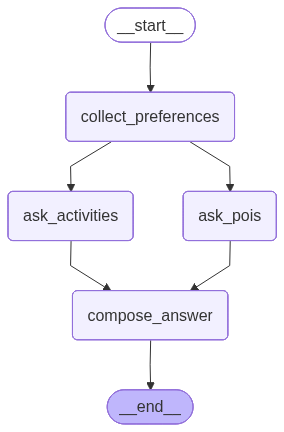

In [181]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
initial = TravelGuideState(
    messages=[HumanMessage("I like street food and wine tasting. I will travel to Florence.")],
    city="",
    activity=None,
    pois_offers=[],
    activities_offers=[]
)
config = RunnableConfig(configurable = {"thread_id": "demo-thread-1"})
final_result1 = app.invoke(initial, config=config)


## Running collect_preferences node ##
##############################
city='Florence' activity='street food and wine tasting'
##############################
## Running ask_activities node ##
## Running ask_sights node ##


In [171]:
dump_state(final_result1)

{
  "messages": [
    {
      "type": "human",
      "content": "I like street food and wine tasting. I will travel to Florence.",
      "id": "4a43b932-ae74-42f2-b38c-79371bd3ab2b"
    }
  ],
  "city": "Florence",
  "activity": "street food and wine tasting",
  "pois_offers": [
    {
      "name": "Duomo (Florence Cathedral)",
      "description": "A magnificent Renaissance cathedral famous for its massive dome designed by Brunelleschi.",
      "why_visit": "Its architectural grandeur is awe-inspiring, and climbing to the top offers unparalleled panoramic views of Florence."
    },
    {
      "name": "Uffizi Gallery",
      "description": "One of the most important art museums in the world, housing masterpieces of the Italian Renaissance.",
      "why_visit": "Home to iconic works by Botticelli, Leonardo da Vinci, Michelangelo, and Raphael, it's an essential stop for art lovers."
    },
    {
      "name": "Ponte Vecchio",
      "description": "A medieval stone arch bridge over the A

C:\Users\jakub.mlacki\AppData\Local\Temp\ipykernel_51224\20808241.py:60: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  return item.dict()


In [172]:
final_result2 = app.invoke(
    {"messages": [HumanMessage("Now I'm going to visit Tokyo")]},
    config=config
)


## Running collect_preferences node ##
##############################
city='Tokyo' activity=None
##############################
## Running ask_activities node ##
   (No activity focus - skipping)
## Running ask_sights node ##
## Running compose_answer node ##


In [173]:
dump_state(final_result2)

{
  "messages": [
    {
      "type": "human",
      "content": "I like street food and wine tasting. I will travel to Florence.",
      "id": "4a43b932-ae74-42f2-b38c-79371bd3ab2b"
    },
    {
      "type": "human",
      "content": "Now I'm going to visit Tokyo",
      "id": "43bc7560-c572-4c17-8f15-2149a55d1cb5"
    }
  ],
  "city": "Tokyo",
  "activity": null,
  "pois_offers": [
    {
      "name": "Senso-ji Temple",
      "description": "A historic Buddhist temple located in Asakusa, Tokyo. It is Tokyo's oldest temple and a significant cultural landmark.",
      "why_visit": "Experience traditional Japanese culture, explore the vibrant Nakamise-dori market leading to the temple, and admire the stunning architecture."
    },
    {
      "name": "Shibuya Crossing",
      "description": "The world's busiest intersection, located in the Shibuya district. It's a famous symbol of modern Tokyo.",
      "why_visit": "Witness the organized chaos of thousands of people crossing simultaneou

C:\Users\jakub.mlacki\AppData\Local\Temp\ipykernel_51224\20808241.py:60: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  return item.dict()


In [174]:
# After Tokyo query
print("\n" + "="*50)
print("COMPLETE MULTI-CITY TRIP PLAN")
print("="*50)
from IPython.display import Markdown, display
display(Markdown(final_result2["result"]))


COMPLETE MULTI-CITY TRIP PLAN


# Florence Travel Guide

Welcome to Florence, the cradle of the Renaissance and a vibrant city filled with art, history, and culinary delights. From its stunning architecture to its world-renowned museums, Florence offers a unique blend of cultural experiences that will leave you enchanted. Whether you're wandering through historic streets or indulging in delectable local cuisine, there's always something new to discover in this Italian gem.

## Points of Interest

### Duomo (Florence Cathedral)
A magnificent Renaissance cathedral famous for its massive dome designed by Brunelleschi.  
**Why Visit:** Its architectural grandeur is awe-inspiring, and climbing to the top offers unparalleled panoramic views of Florence.

### Uffizi Gallery
One of the most important art museums in the world, housing masterpieces of the Italian Renaissance.  
**Why Visit:** Home to iconic works by Botticelli, Leonardo da Vinci, Michelangelo, and Raphael, it's an essential stop for art lovers.

### Ponte Vecchio
A medieval stone arch bridge over the Arno River, uniquely lined with shops built along it.  
**Why Visit:** It's a picturesque and historic landmark, offering a charming stroll with beautiful views and a glimpse into medieval commerce.

## Activities

### Florentine Street Food Tour
Embark on a guided tour through the streets of Florence, tasting local specialties such as lampredotto, porchetta sandwiches, and sweet treats like cantucci. The tour provides insights into the culinary culture of Florence, highlighting the best spots for authentic street food.  
**Relevance:** This activity is directly focused on street food, allowing you to sample Florence's best quick eats and learn about the local food culture.

### Wine Tasting at Enoteca Pitti Gola e Cantina
Located near the Pitti Palace, this wine bar offers an extensive selection of Tuscan wines for tasting. Enjoy guided tastings with expert advice on wine pairings and learn about the local wine-making traditions, especially Chianti.  
**Relevance:** This spot is perfect for experiencing wine tasting in a relaxed atmosphere and is relevant due to its emphasis on regional wines, enhancing your culinary journey through Florence.

### Street Food & Wine Pairing Experience
This unique experience combines the best of street food and wine, where participants can try a variety of local street foods, paired with tastings of regional wines that complement the flavors of the dishes.  
**Relevance:** It perfectly merges your interests by allowing you to indulge in both street food and wine tasting in one guided experience, showcasing how the two complement each other.

Rediscover the joy of travel in Florence, and immerse yourself in its enchanting atmosphere filled with exquisite art, unforgettable sights, and mouthwatering cuisine.

# Tokyo Travel Guide

Welcome to Tokyo, a vibrant metropolis where tradition meets modernity! This captivating city is known for its stunning skyline, rich history, and endless opportunities for adventure. Whether you're wandering through ancient temples or navigating busy streets filled with neon lights, Tokyo offers an experience unlike any other. Get ready to immerse yourself in the unique culture and excitement that awaits in this incredible city!

## Points of Interest

### Senso-ji Temple
- **Description:** A historic Buddhist temple located in Asakusa, Tokyo. It is Tokyo's oldest temple and a significant cultural landmark.
- **Why Visit:** Experience traditional Japanese culture, explore the vibrant Nakamise-dori market leading to the temple, and admire the stunning architecture.

### Shibuya Crossing
- **Description:** The world's busiest intersection, located in the Shibuya district. It's a famous symbol of modern Tokyo.
- **Why Visit:** Witness the organized chaos of thousands of people crossing simultaneously, soak in the energetic atmosphere, and enjoy the surrounding neon lights and giant video screens.

### Meiji Jingu Shrine
- **Description:** A peaceful Shinto shrine dedicated to Emperor Meiji and Empress Shoken, set within a serene forest in the heart of Tokyo.
- **Why Visit:** Escape the city's hustle and bustle in a tranquil oasis, learn about Japanese imperial history, and admire the traditional shrine architecture surrounded by nature.

## Activities

- **General Sightseeing:** While specific activities aren't listed, the best way to experience Tokyo is by exploring the diverse neighborhoods, tasting local cuisine, and visiting the multitude of vibrant markets and shopping districts. Don't forget to take a stroll through the beautiful parks and gardens that dot the city!

Tokyo is a metropolis that promises unforgettable memories and an ever-expanding list of things to see and do. Pack your bags and get ready for an adventure of a lifetime!

